In [1]:
import torch

def check_gpu_status():
    """
    Checks for CUDA availability and displays details for all available GPUs.
    """
    if torch.cuda.is_available():
        print("✅ CUDA is available! PyTorch can use the GPU.")
        
        # Get the number of available GPUs
        num_gpus = torch.cuda.device_count()
        print(f"Number of available GPUs: {num_gpus}\n")
        
        for i in range(num_gpus):
            # Get properties for each GPU
            gpu_properties = torch.cuda.get_device_properties(i)
            
            # Display information
            print(f"--- GPU Device Index: {i} ---")
            print(f"GPU Name: {gpu_properties.name}")
            
            # Convert total memory from bytes to GB
            total_memory_gb = gpu_properties.total_memory / (1024**3)
            print(f"Total VRAM: {total_memory_gb:.2f} GB")
            print(f"CUDA Capability: {gpu_properties.major}.{gpu_properties.minor}")
            
            # Get current memory usage (allocated and cached)
            allocated_mb = torch.cuda.memory_allocated(i) / (1024**2)
            cached_mb = torch.cuda.memory_reserved(i) / (1024**2)
            print(f"Allocated Memory: {allocated_mb:.2f} MB")
            print(f"Reserved/Cached Memory: {cached_mb:.2f} MB")
            
    else:
        print("❌ CUDA is NOT available. PyTorch is running on the CPU.")

# Run the function to display your GPU status
check_gpu_status()

✅ CUDA is available! PyTorch can use the GPU.
Number of available GPUs: 1

--- GPU Device Index: 0 ---
GPU Name: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Total VRAM: 4.00 GB
CUDA Capability: 8.6
Allocated Memory: 0.00 MB
Reserved/Cached Memory: 0.00 MB


In [1]:
from datasets import load_dataset, load_from_disk
import os

In [5]:


# Get absolute path to data directory (relative to this notebook's location)
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir) if notebook_dir.endswith("src") else os.path.dirname(os.getcwd())
# Handle case where we're running from src directory
if os.getcwd().endswith("src"):
    project_root = os.path.dirname(os.getcwd())
else:
    project_root = os.getcwd()
print ("project root: "+project_root)
data_dir = os.path.join(project_root, "ROCOv2-radiology", "data")
cache_dir = os.path.join(project_root, "src")  # Cache in src folder

print(f"Data directory: {data_dir}")
print(f"Files exist: {os.path.exists(data_dir)}")

# Check if cached version exists for faster loading
train_cache = os.path.join(cache_dir, "roco_train_full")
val_cache = os.path.join(cache_dir, "roco_validation_full")
test_cache = os.path.join(cache_dir, "roco_test_full")

if os.path.exists(train_cache):
    print("Loading from cached Arrow format (fast)...")
    train_dataset = load_from_disk(train_cache)
    val_dataset = load_from_disk(val_cache)
    test_dataset = load_from_disk(test_cache)
else:
    print("Loading from parquet files (first time)...")
    # Use absolute paths with glob pattern
    train_files = os.path.join(data_dir, "train-*.parquet")
    val_files = os.path.join(data_dir, "validation-*.parquet")
    test_files = os.path.join(data_dir, "test-*.parquet")
    
    train_dataset = load_dataset("parquet", data_files=train_files, split="train")
    val_dataset = load_dataset("parquet", data_files=val_files, split="train")
    test_dataset = load_dataset("parquet", data_files=test_files, split="train")
    
    # Cache for faster subsequent loads
    train_dataset.save_to_disk(train_cache)
    val_dataset.save_to_disk(val_cache)
    test_dataset.save_to_disk(test_cache)
    print("✓ Cached to disk")

print(f"\nDataset loaded:")
print(f"Train: {len(train_dataset):,} samples")
print(f"Validation: {len(val_dataset):,} samples")
print(f"Test: {len(test_dataset):,} samples")

project root: c:\Users\charb\OneDrive\Desktop\deep learning final project
Data directory: c:\Users\charb\OneDrive\Desktop\deep learning final project\ROCOv2-radiology\data
Files exist: True
Loading from parquet files (first time)...


Generating train split: 59962 examples [00:20, 2871.93 examples/s]

Generating train split: 9904 examples [00:04, 2435.20 examples/s]

Generating train split: 9927 examples [00:04, 2401.76 examples/s]

Saving the dataset (6/6 shards): 100%|██████████| 9904/9904 [00:09<00:00, 1084.73 examples/s]

Saving the dataset (6/6 shards): 100%|██████████| 9927/9927 [00:09<00:00, 1038.09 examples/s]

✓ Cached to disk

Dataset loaded:
Train: 59,962 samples
Validation: 9,904 samples
Test: 9,927 samples


In [2]:
# ===== From now on, use this (super fast) =====
train_dataset = load_from_disk("roco_train_full")
val_dataset = load_from_disk("roco_validation_full")
test_dataset = load_from_disk("roco_test_full")

print(f"\nLoaded instantly:")
print(f"Train: {len(train_dataset)} samples")
print(f"Validation: {len(val_dataset)} samples")
print(f"Test: {len(test_dataset)} samples")

Loading dataset from disk:   0%|          | 0/27 [00:00<?, ?it/s]


Loaded instantly:
Train: 59962 samples
Validation: 9904 samples
Test: 9927 samples


In [3]:
train_dataset

Dataset({
    features: ['image', 'image_id', 'caption', 'cui'],
    num_rows: 59962
})

In [8]:
from transformers import BitsAndBytesConfig
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    llm_int8_enable_fp32_cpu_offload=True  # Enable CPU offloading
)

In [13]:

from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

MODEL_NAME = "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit"  # Local testing
# MODEL_NAME = "unsloth/llava-1.5-7b-hf-bnb-4bit"     # Colab training

model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_NAME,
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
    device_map = "auto",
    offload_embedding = True,
    quantization_config=bnb_config,  
)



==((====))==  Unsloth 2025.11.2: Fast Qwen2_Vl patching. Transformers: 4.57.0. vLLM: 0.10.2.
   \\   /|    NVIDIA GeForce RTX 3050 Ti Laptop GPU. Num GPUs = 1. Max memory: 4.0 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33+aa7bc36.d20251112. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Offloading embeddings to RAM to save 0.43 GB.


In [14]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.model.visual` require gradients


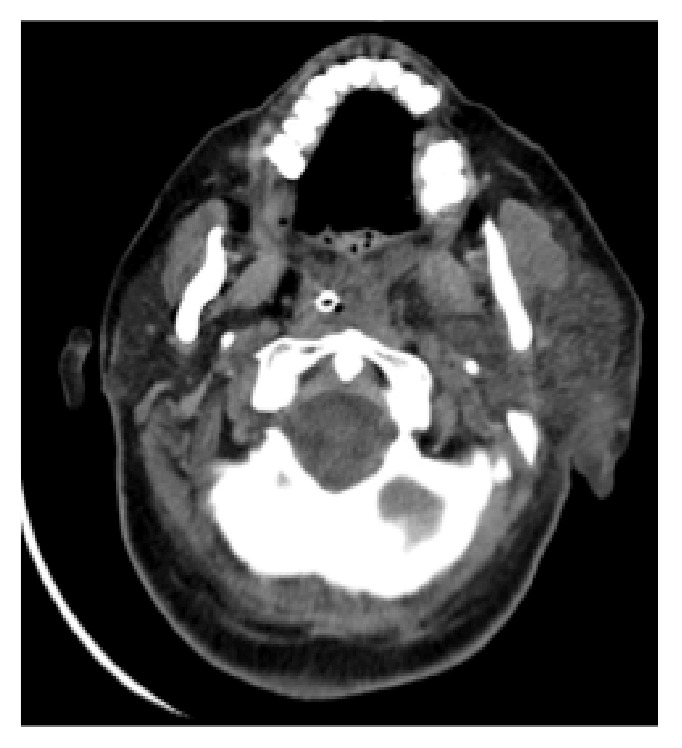

In [21]:
train_dataset[0]["image"]

In [4]:
train_dataset[0]["caption"]

'Head CT demonstrating left parotiditis.'

In [4]:
instruction = "You are an expert radiographer. Describe accurately what you see in this image."

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["caption"]} ]
        },
    ]
    return { "messages" : conversation }
pass

In [5]:
import os

# Optimal number of workers (leave some cores free)
num_workers = max(1, os.cpu_count() - 2)

# Use map() with parallel processing for speed
converted_train_dataset = train_dataset.map(
    convert_to_conversation,  # No need for lambda wrapper
    remove_columns=train_dataset.column_names,
    num_proc=num_workers,  # Parallel processing
    desc="Converting train"
)

converted_test_dataset = test_dataset.map(
    convert_to_conversation,
    remove_columns=test_dataset.column_names,
    num_proc=num_workers,
    desc="Converting test"
)

converted_validation_dataset = val_dataset.map(
    convert_to_conversation,
    remove_columns=val_dataset.column_names,
    num_proc=num_workers,
    desc="Converting validation"
)

print(f"✓ Converted datasets (using {num_workers} workers):")
print(f"  Train: {len(converted_train_dataset)} samples")
print(f"  Test: {len(converted_test_dataset)} samples")  
print(f"  Validation: {len(converted_validation_dataset)} samples")

Converting train (num_proc=14):   0%|          | 0/59962 [00:00<?, ? examples/s]

RuntimeError: One of the subprocesses has abruptly died during map operation.To debug the error, disable multiprocessing.

In [ ]:
# Save converted datasets to disk for faster reloading
import os

cache_dir = "./cached_datasets"
os.makedirs(cache_dir, exist_ok=True)

print("Saving converted datasets to disk...")
converted_train_dataset.save_to_disk(f"{cache_dir}/train")
converted_test_dataset.save_to_disk(f"{cache_dir}/test")
converted_validation_dataset.save_to_disk(f"{cache_dir}/validation")
print(f"✓ Datasets cached in {cache_dir}/")

In [ ]:
converted_train_dataset[0]